In [2]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

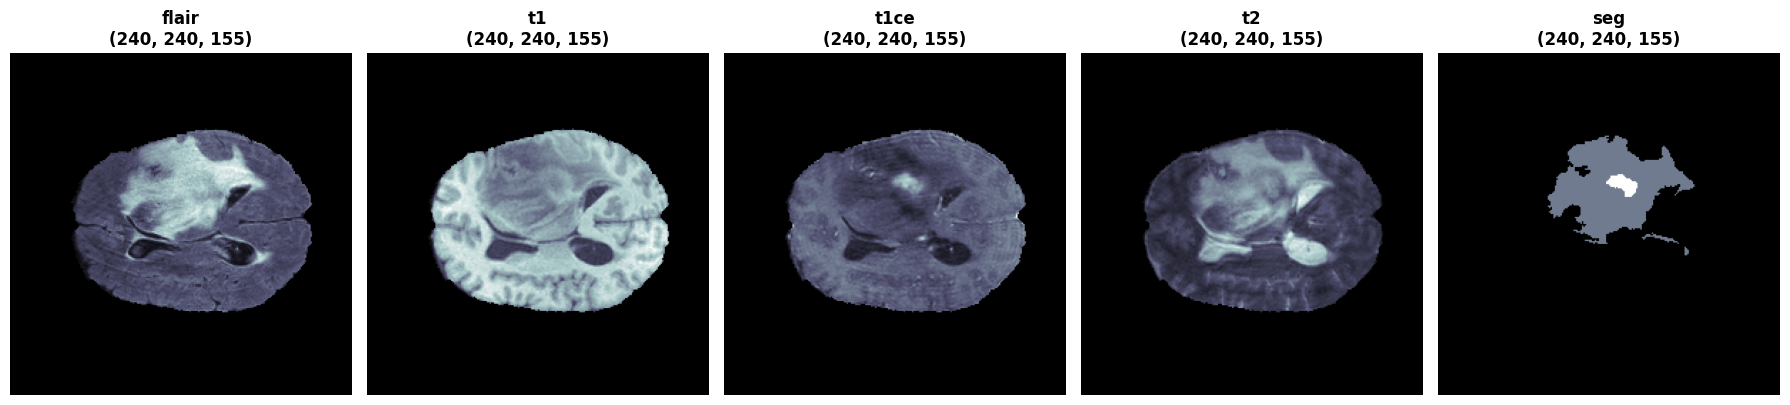

In [3]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 경로 및 설정
base_path = r'C:\Users\109so\OneDrive\Desktop\학교\biohealth_lv.1'
mode = 'Training'  # 'Training' 또는 'Validation'
img_id = '001'

folder_name = f'MICCAI_FeTS2021_{mode}Data'
sub_folder = f'FeTS21_{mode}_{img_id}'
full_path = os.path.join(base_path, folder_name, sub_folder)

# 파일 리스트 (Validation은 seg 제외)
s_types = ['flair', 't1', 't1ce', 't2', 'seg'] if mode == 'Training' else ['flair', 't1', 't1ce', 't2']

plt.figure(figsize=(18, 5))
slice_idx = 80
seg_data = None

for i, s_type in enumerate(s_types):
    # .gz 제거된 파일명 구성
    file_name = f'{sub_folder}_{s_type}.nii'
    file_path = os.path.join(full_path, file_name)
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue
        
    # 데이터 로드
    img_obj = nib.load(file_path)
    # 메모리 효율을 위해 전체를 로드(get_fdata)하지 않고 해당 슬라이스만 추출 가능
    image_slice = img_obj.dataobj[:, :, slice_idx]
    
    if s_type == 'seg':
        seg_data = image_slice # 분석용으로 슬라이스 저장
    
    plt.subplot(1, 5, i+1)
    plt.imshow(image_slice, cmap='bone')
    plt.title(f"{s_type}\n{img_obj.shape}", fontweight='bold')
    plt.axis(False)

plt.tight_layout()
plt.show()

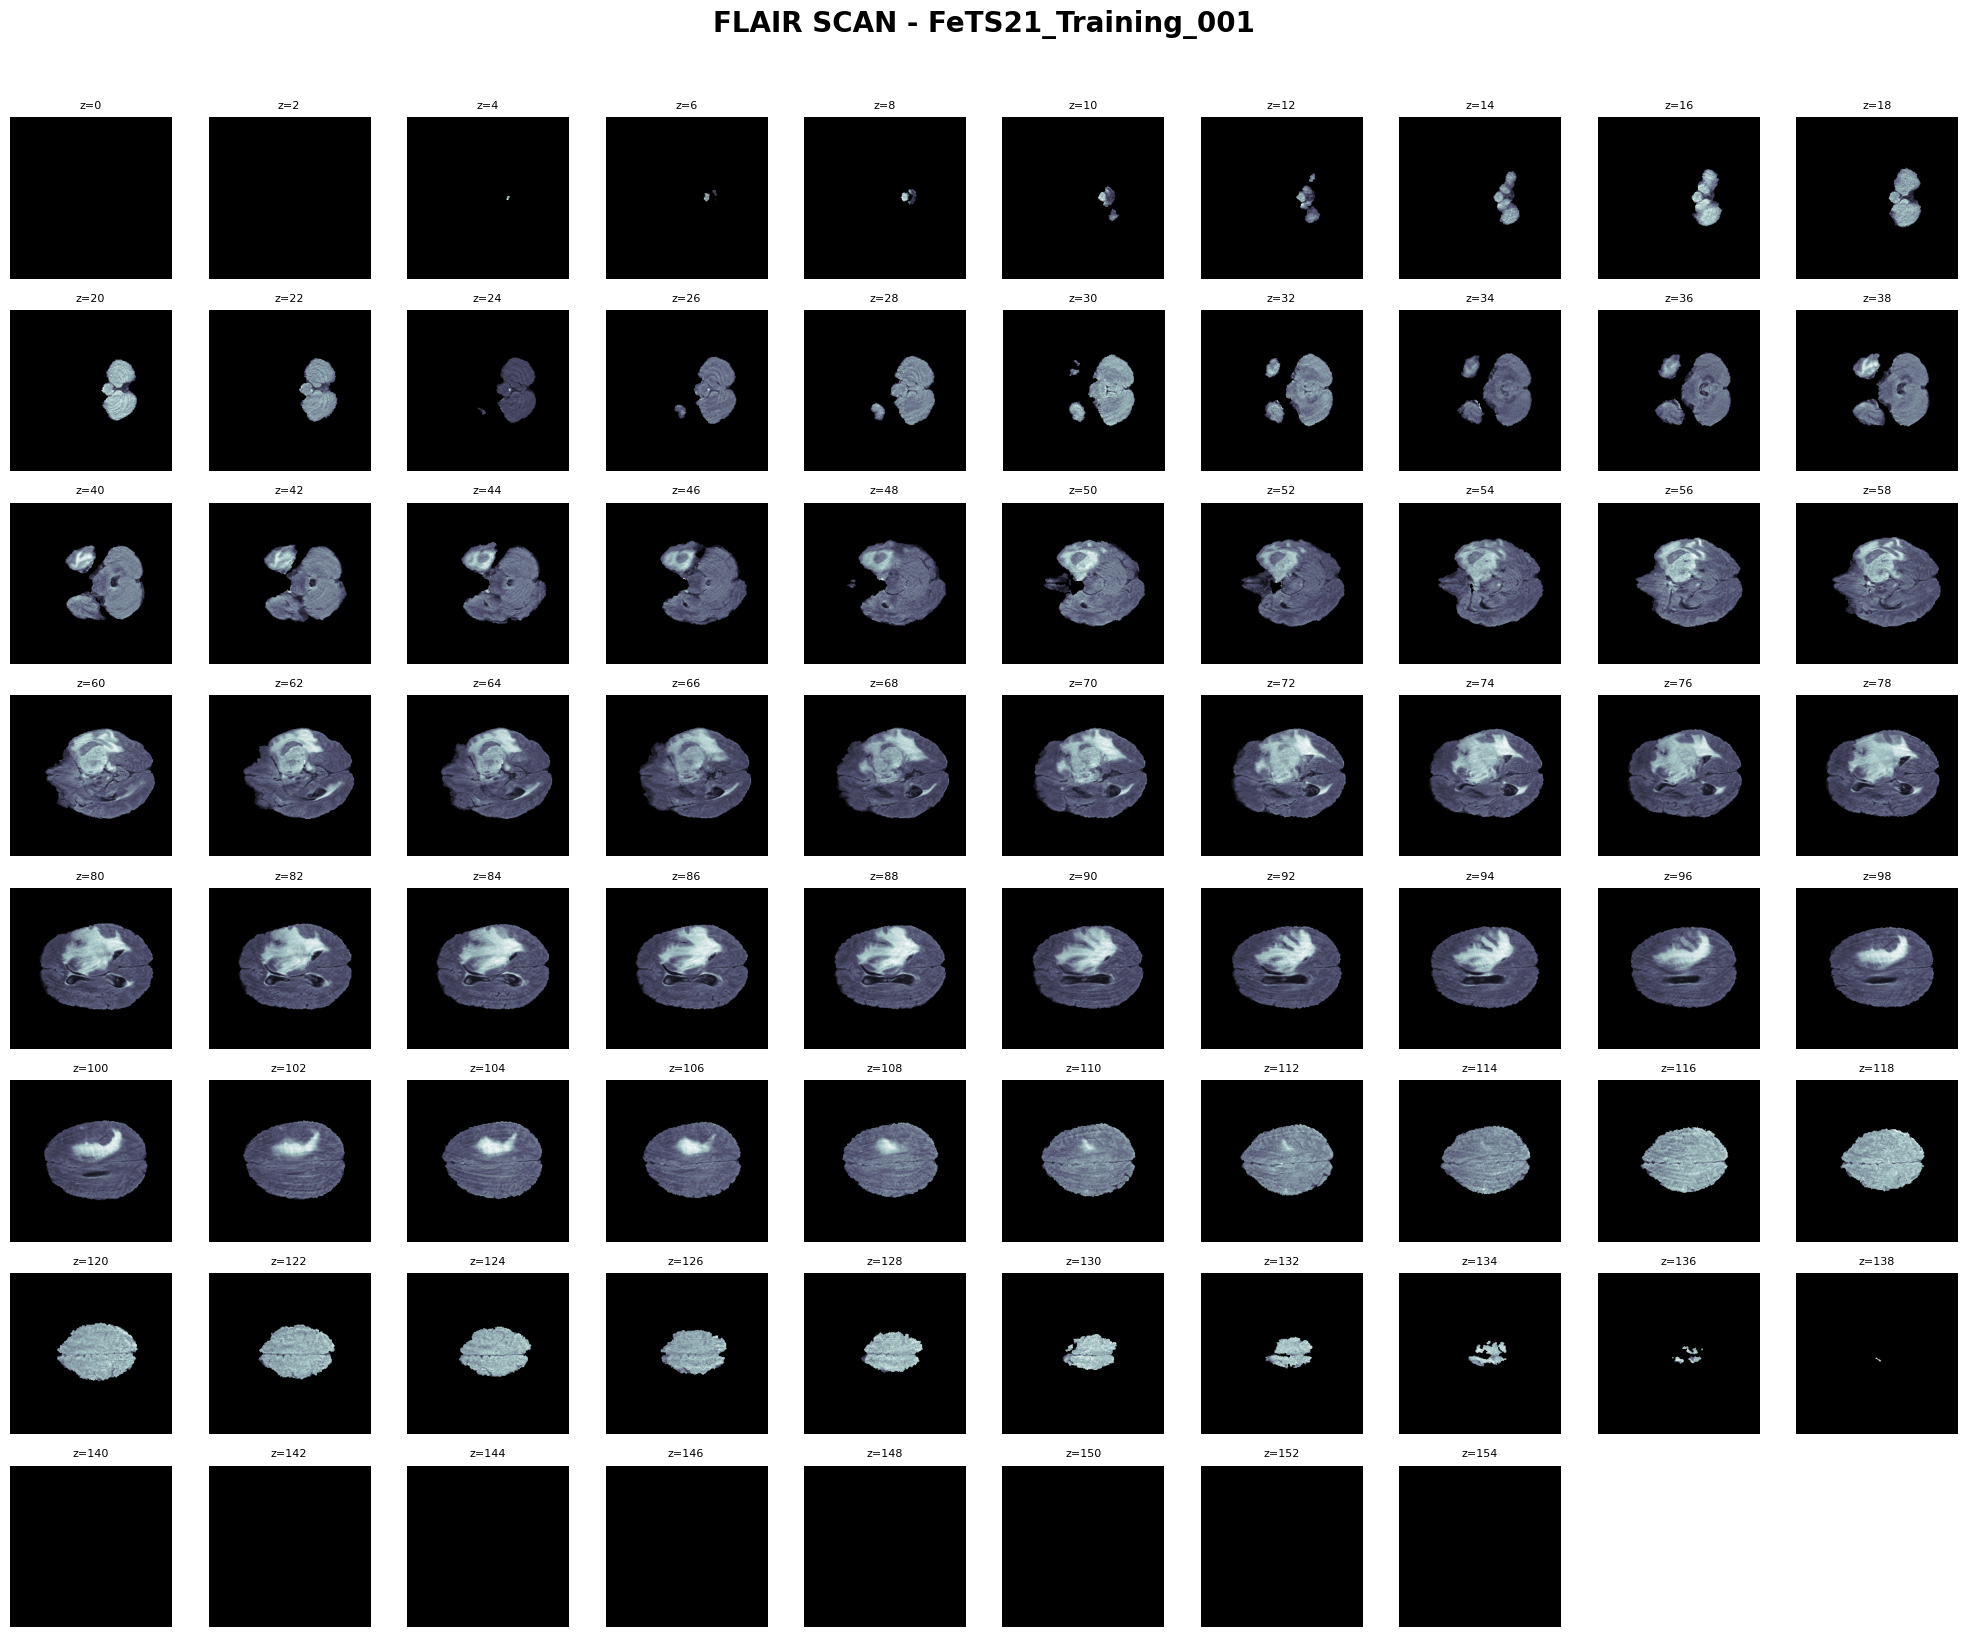

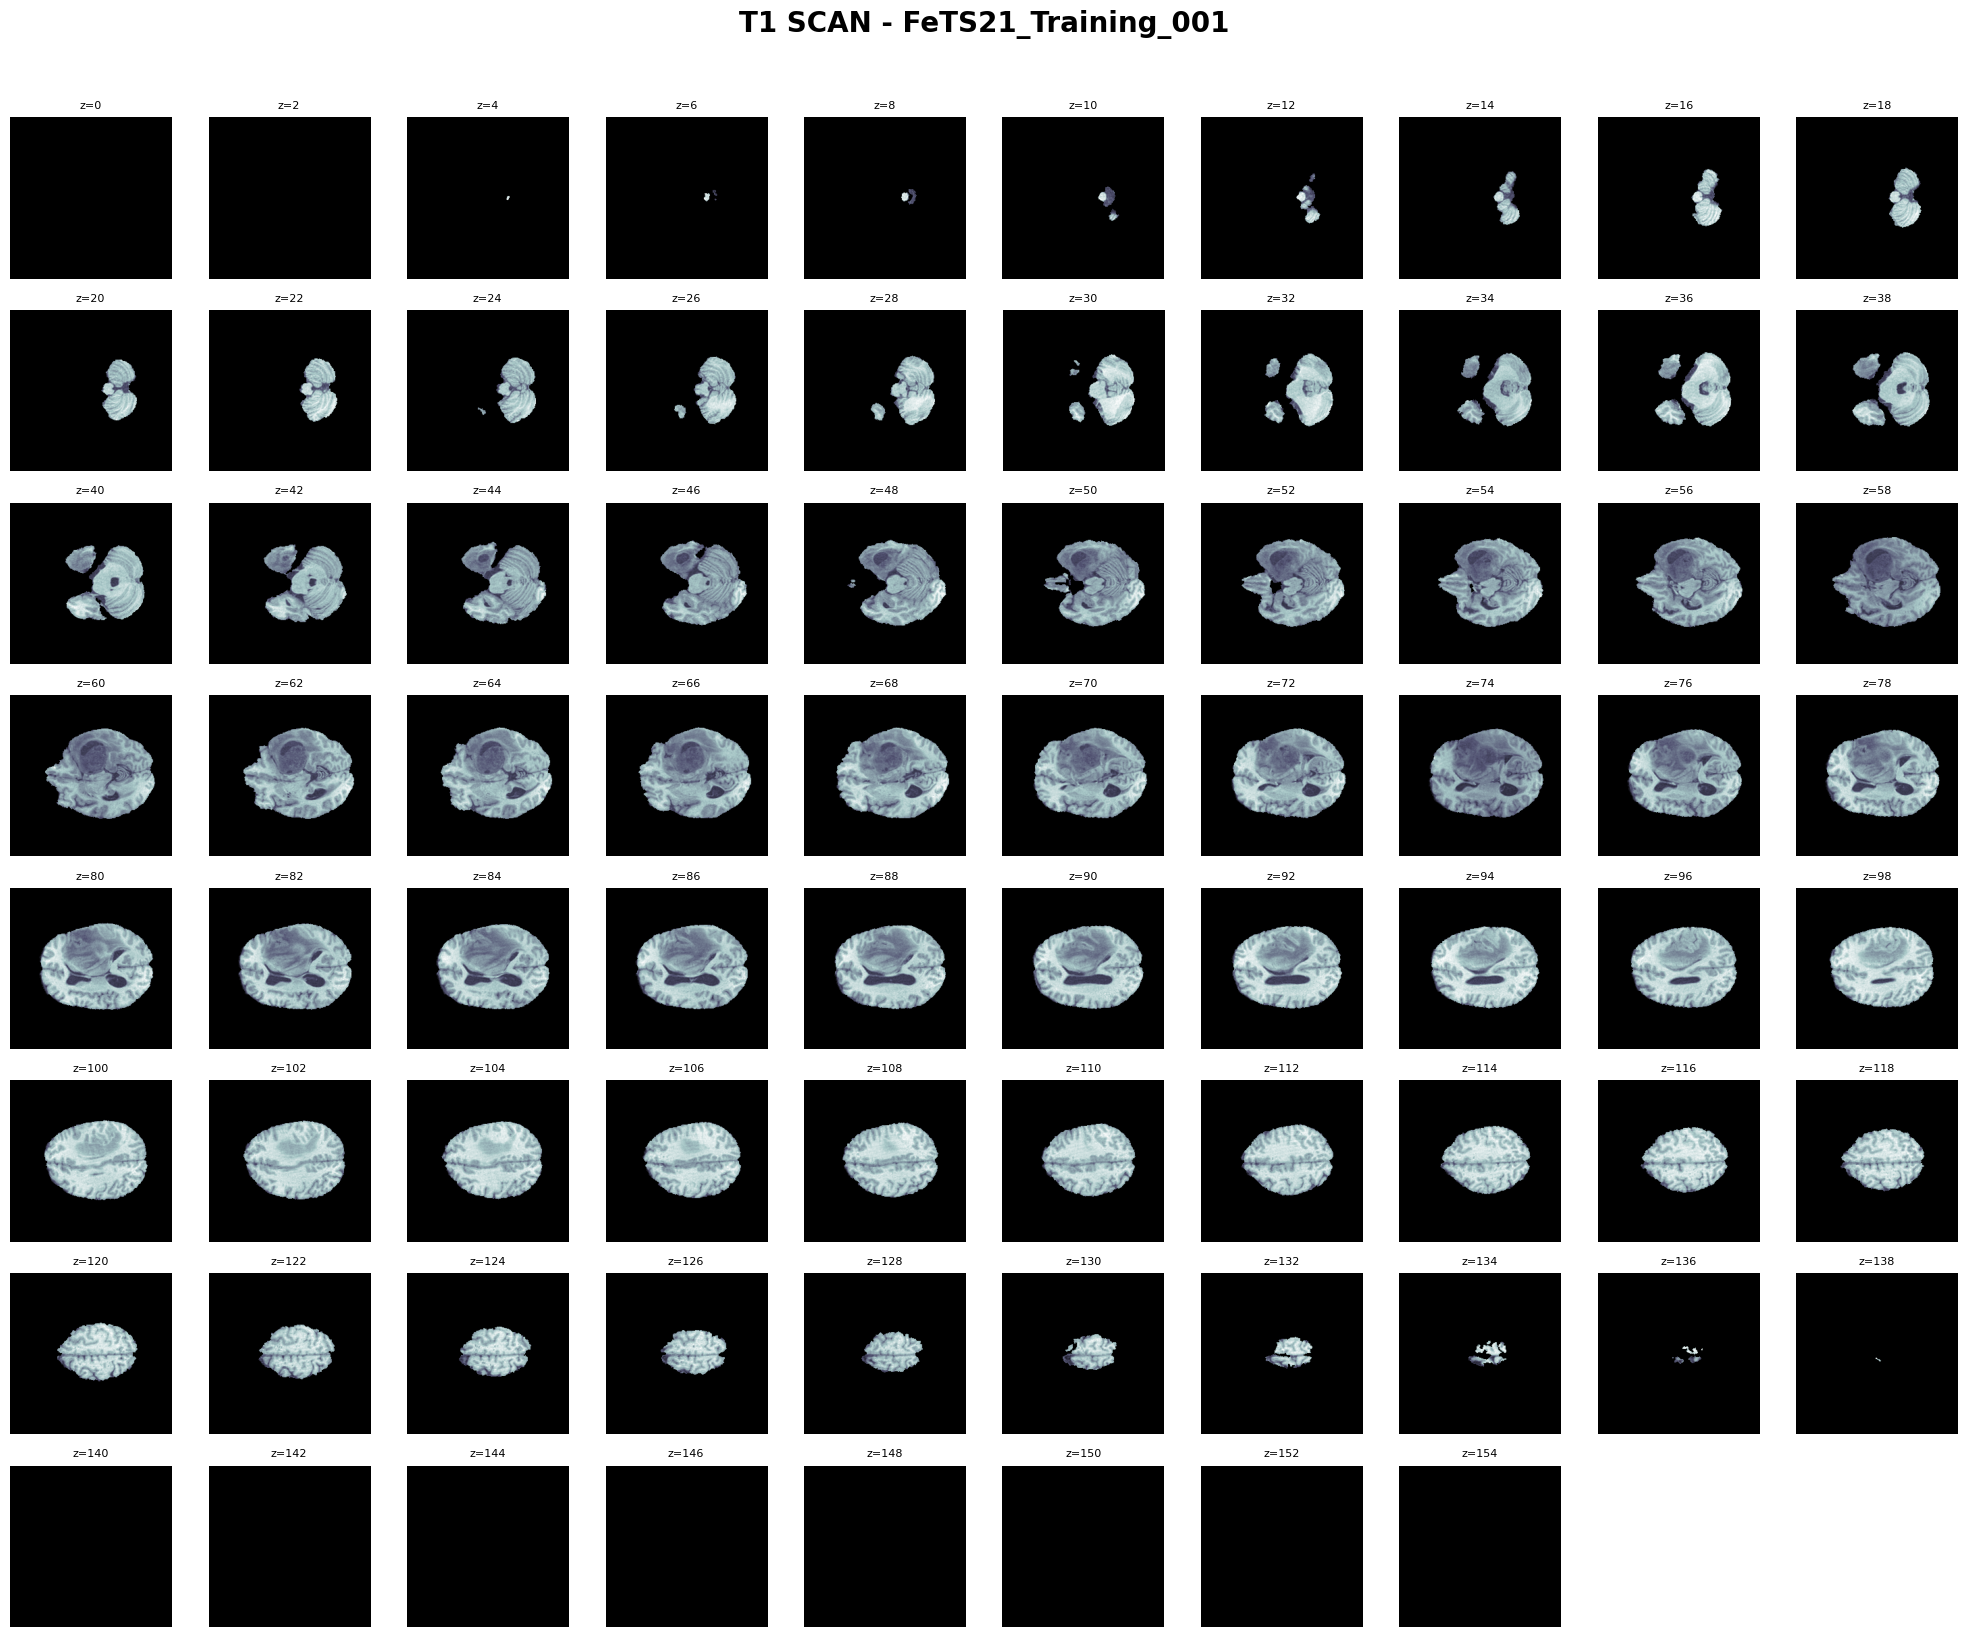

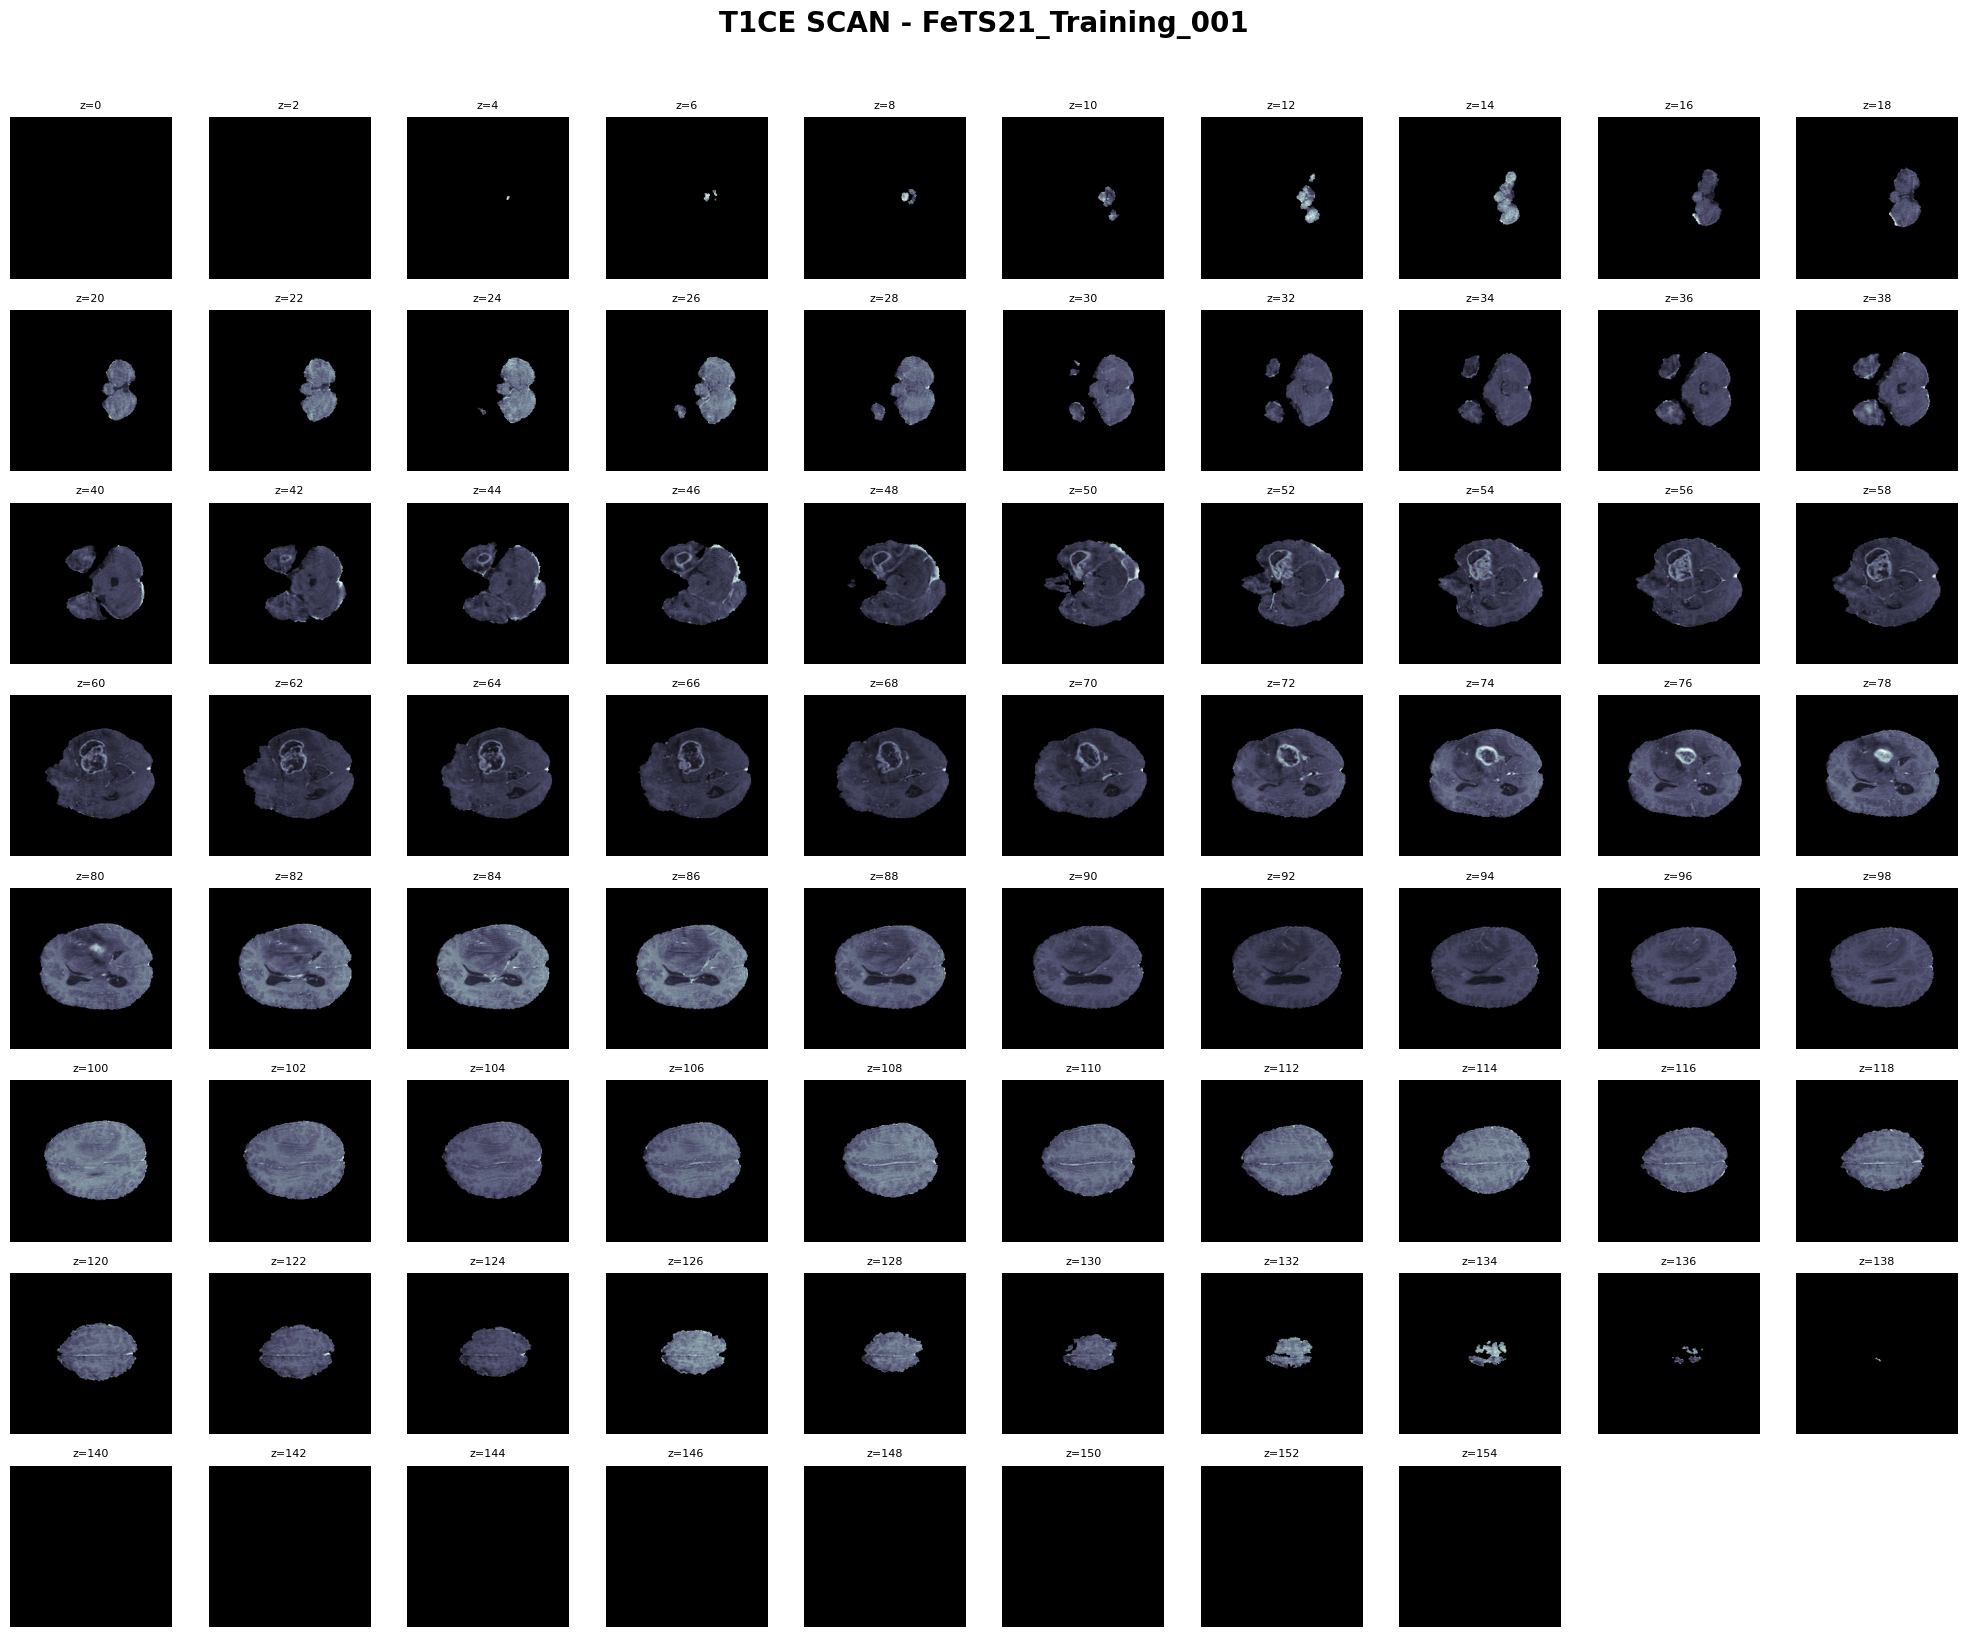

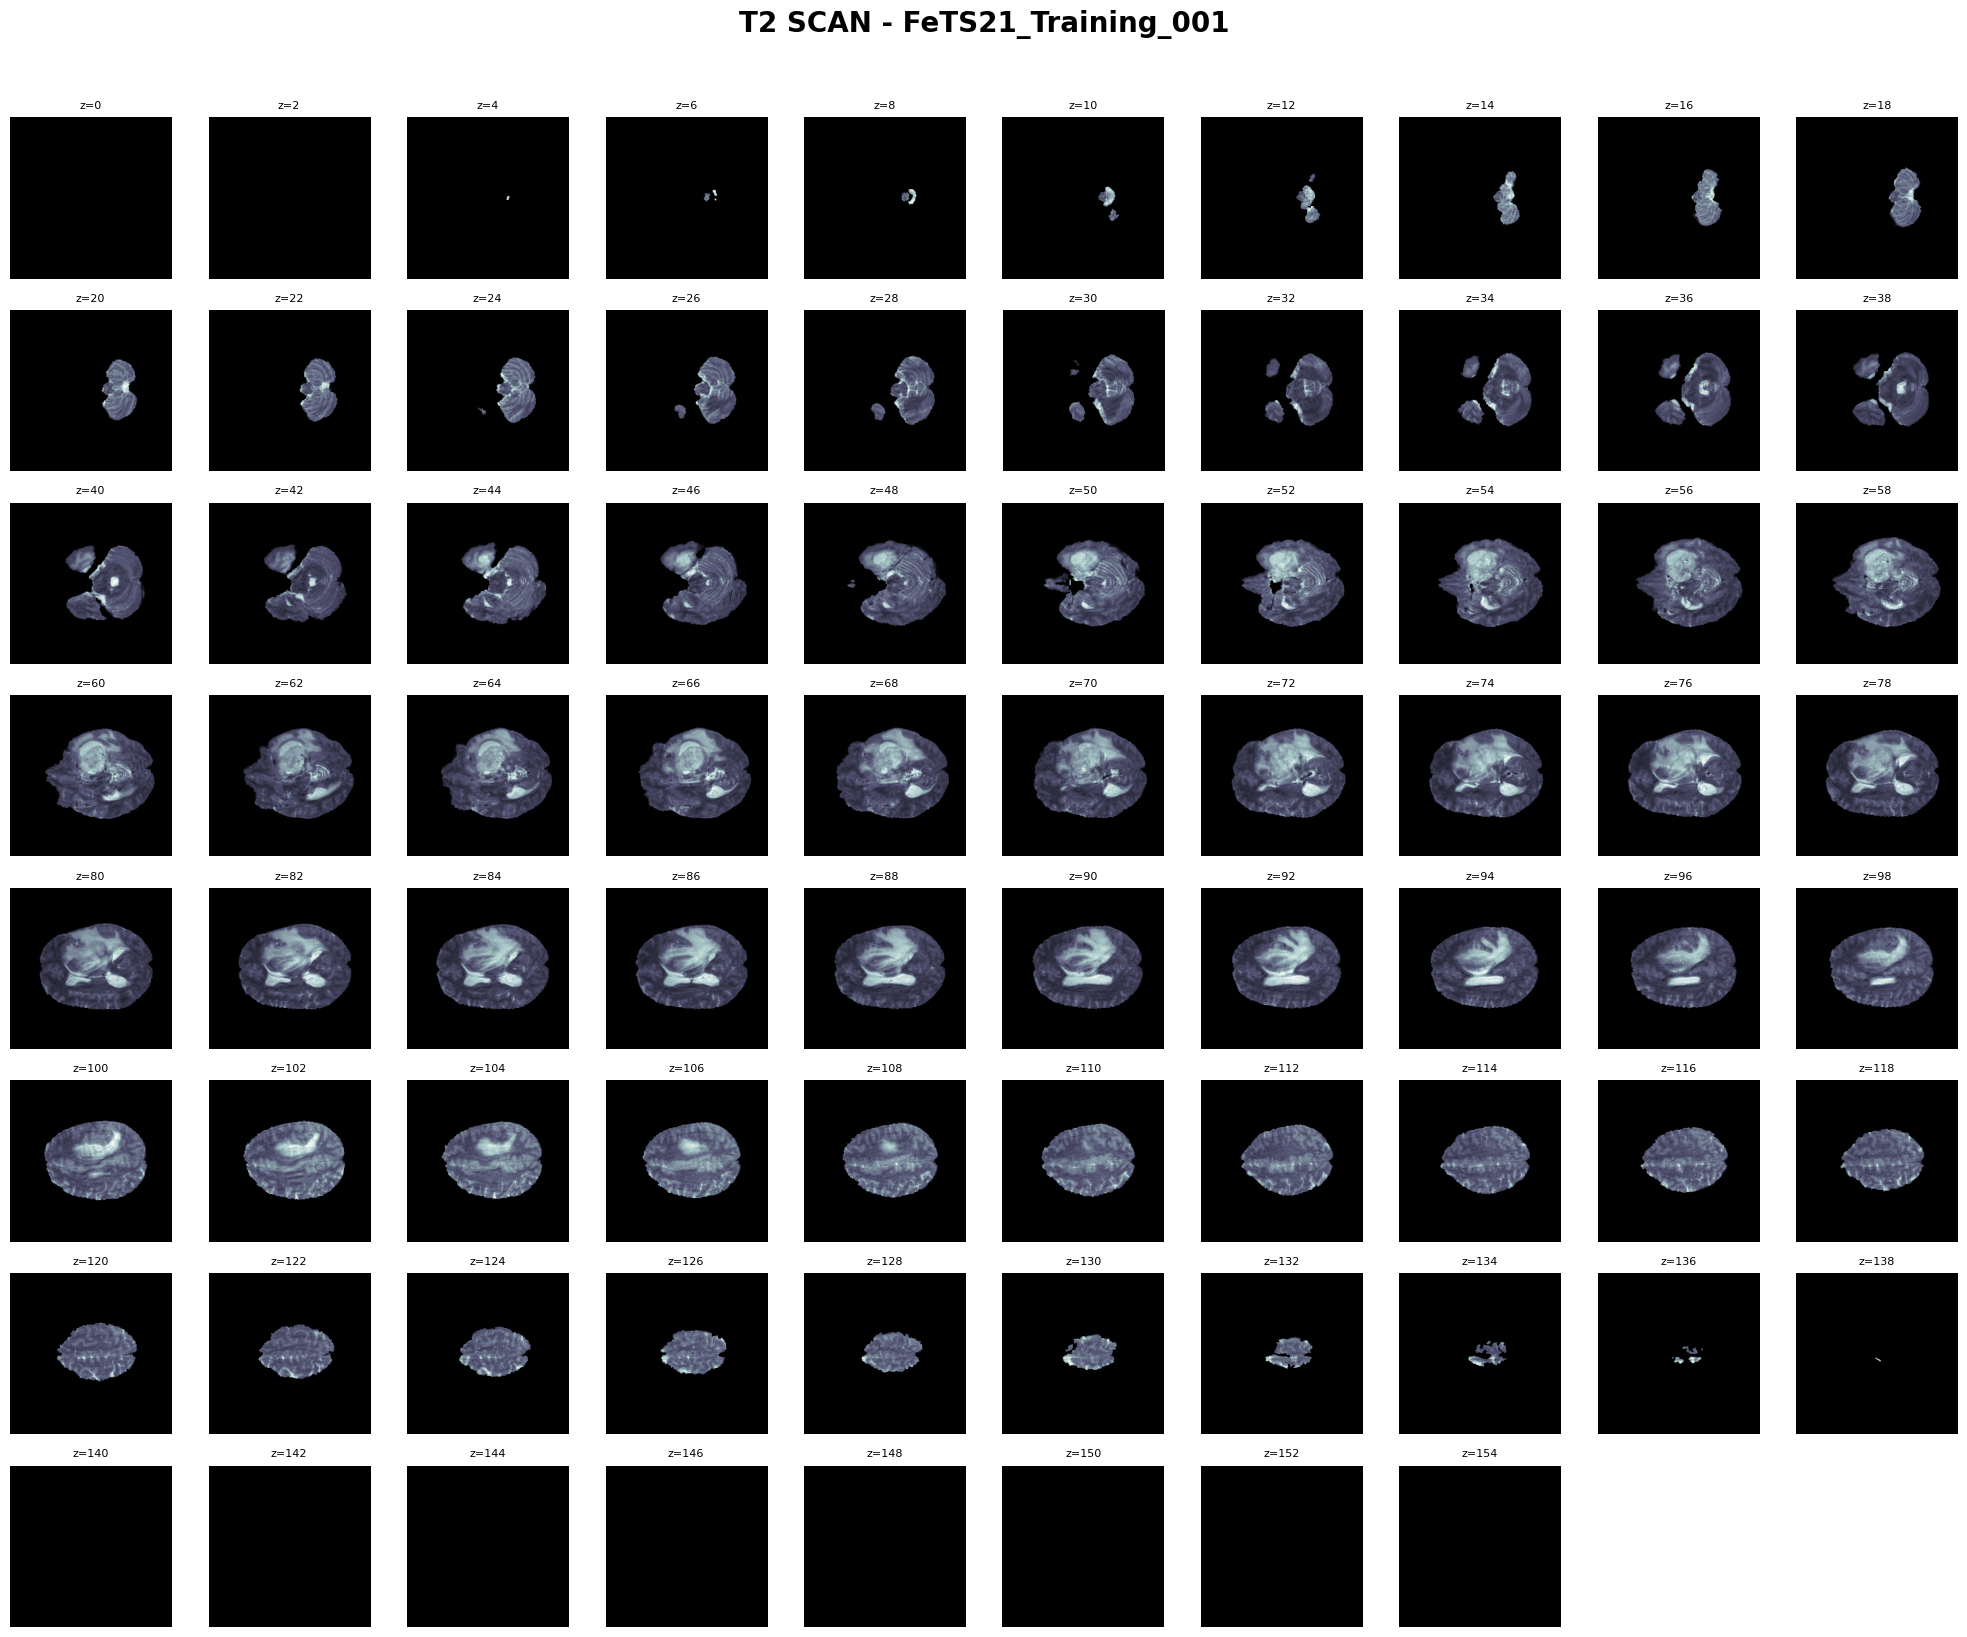

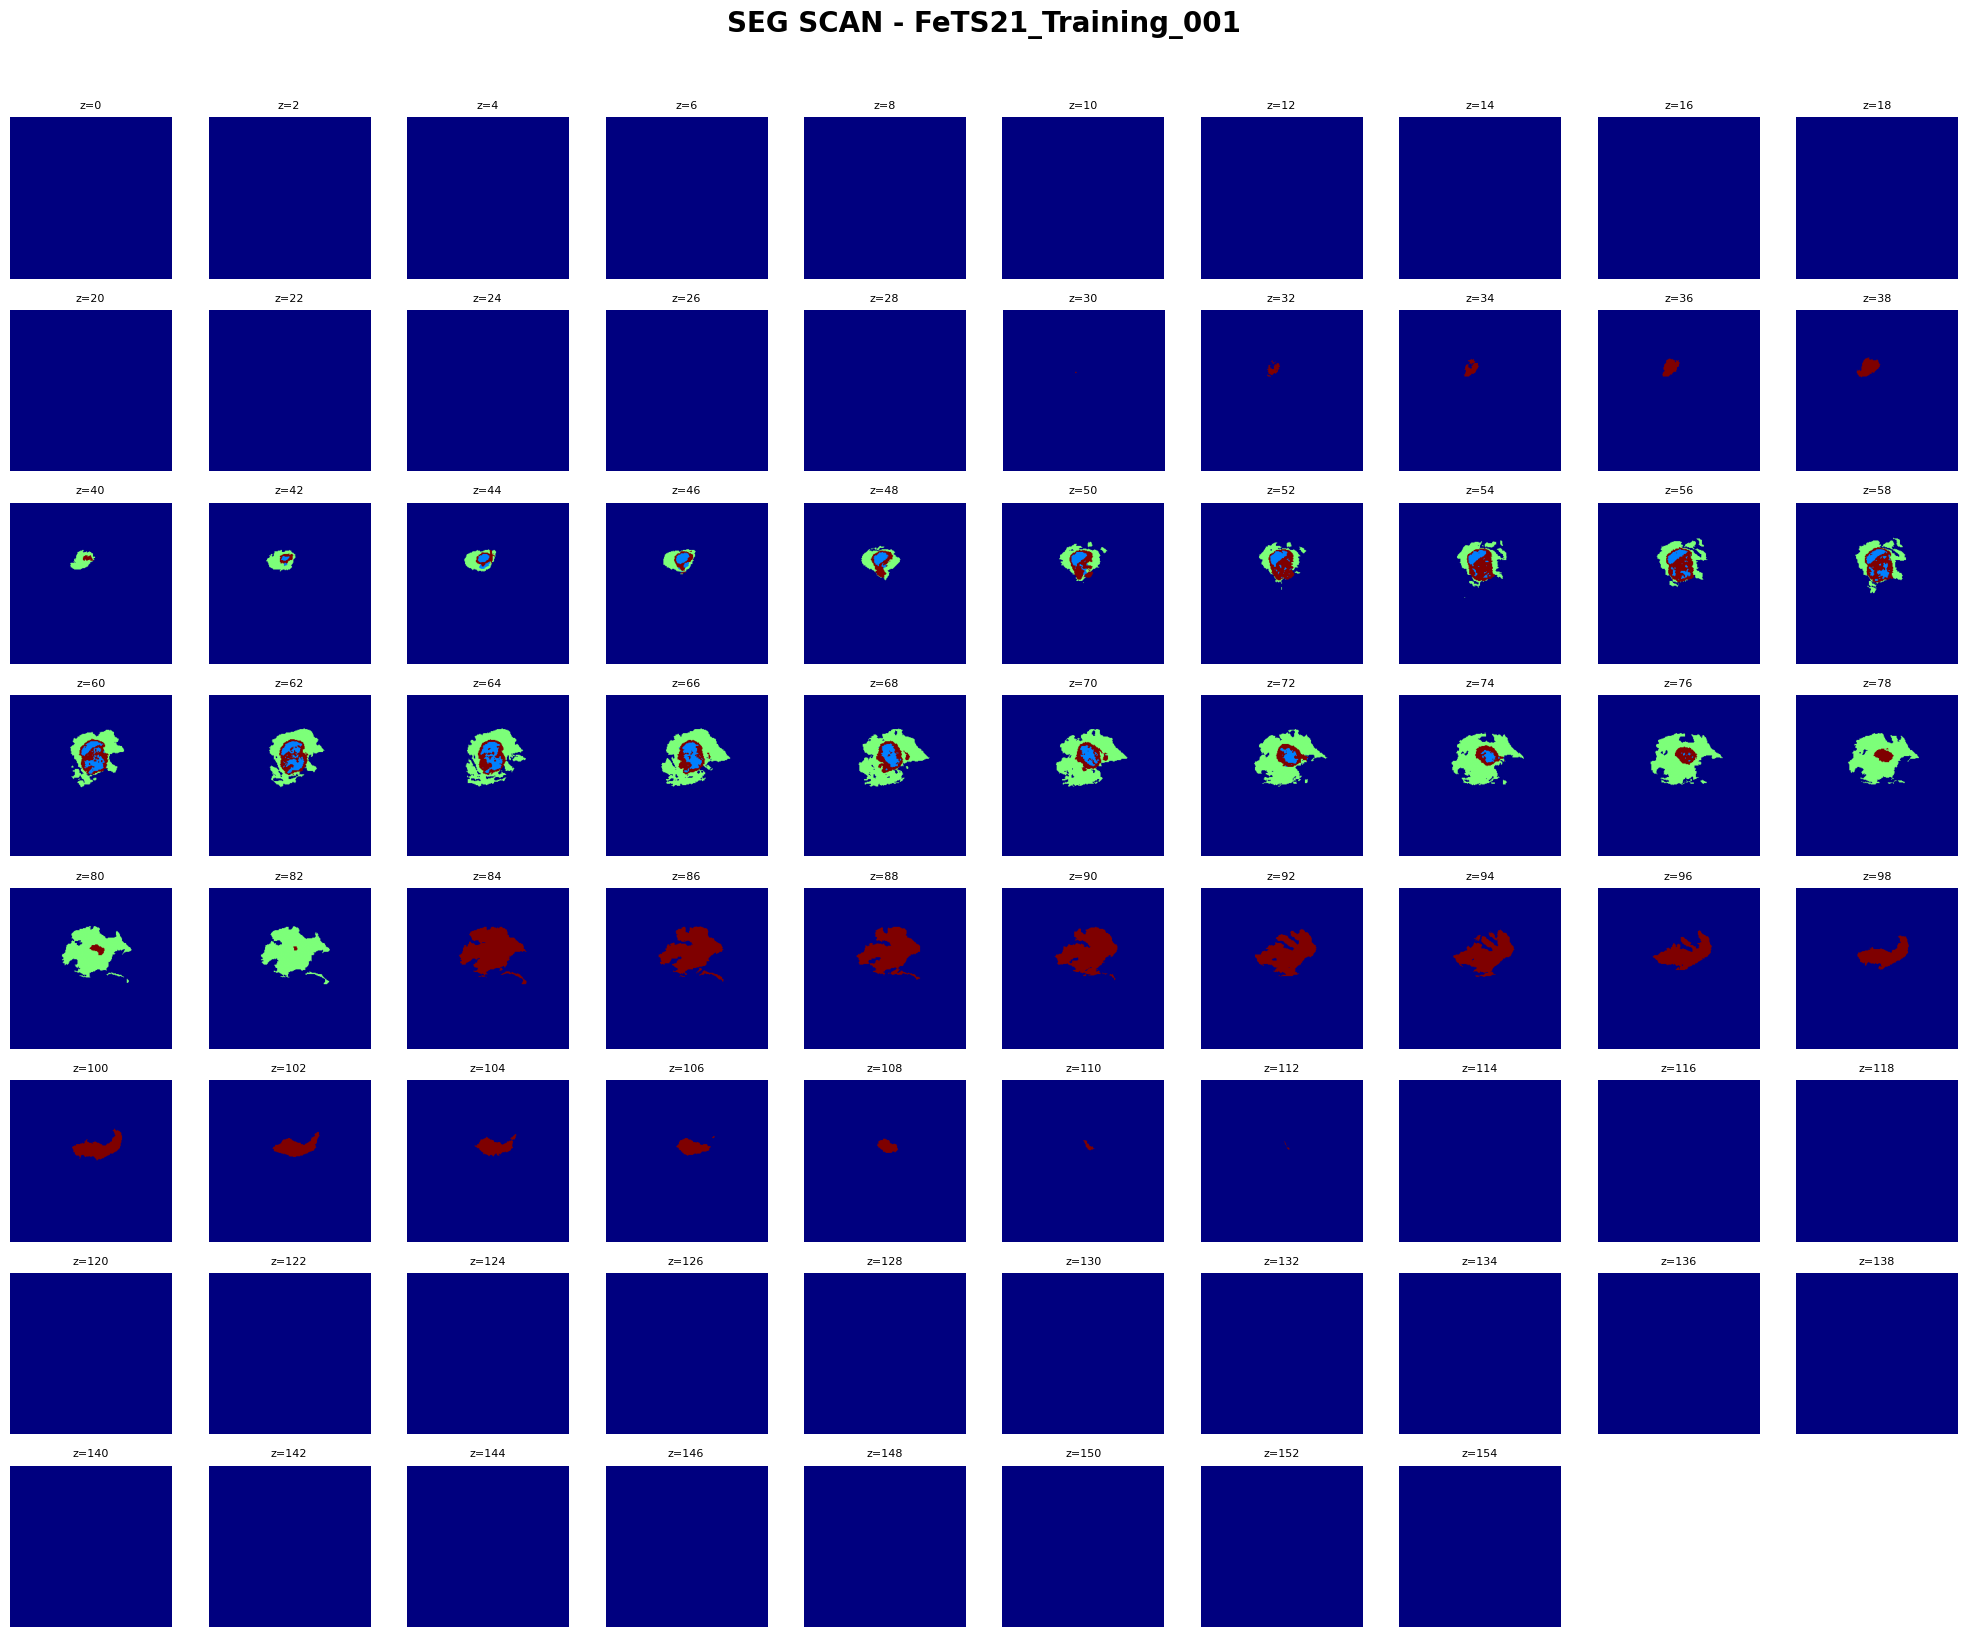

In [4]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 설정
base_path = r'C:\Users\109so\OneDrive\Desktop\학교\biohealth_lv.1'
mode = 'Training'  # 'Training' 또는 'Validation'
img_id = '001'

folder_name = f'MICCAI_FeTS2021_{mode}Data'
sub_folder = f'FeTS21_{mode}_{img_id}'
full_path = os.path.join(base_path, folder_name, sub_folder)

# 파일 리스트 구성
s_types = ['flair', 't1', 't1ce', 't2', 'seg'] if mode == 'Training' else ['flair', 't1', 't1ce', 't2']

# 2. 반복문을 통한 시각화
for s_type in s_types:
    file_name = f'{sub_folder}_{s_type}.nii'
    file_path = os.path.join(full_path, file_name)
    
    if not os.path.exists(file_path):
        print(f"Skipping: {file_name} (Not found)")
        continue
    
    # nibabel 로드 (메모리 효율을 위해 로드 시점 조절)
    img_obj = nib.load(file_path)
    image = img_obj.get_fdata()
    slices = image.shape[-1]
    
    # 행 계산 (2개 슬라이스 간격으로 시각화하므로 slices/2 기준)
    cols = 10
    display_slices = range(0, slices, 2)
    rows = int(np.ceil(len(display_slices) / cols))
    
    # 캔버스 생성
    plt.figure(figsize=(20, rows * 2))
    plt.suptitle(f"{s_type.upper()} SCAN - {sub_folder}", fontsize=20, fontweight="bold", y=1.02)
    
    for idx, j in enumerate(display_slices):
        plt.subplot(rows, cols, idx + 1)
        
        # Segmentation인 경우 가독성을 위해 다른 colormap 적용 가능
        cmap = "bone" if s_type != 'seg' else "jet"
        
        plt.imshow(image[:, :, j], cmap=cmap)
        plt.title(f"z={j}", fontsize=8)
        plt.axis(False)
        
    plt.tight_layout()
    plt.show()
    
    # 한 세트 시각화 후 메모리 점유 방지를 위해 변수 해제 (대용량 처리 시 권장)
    del image

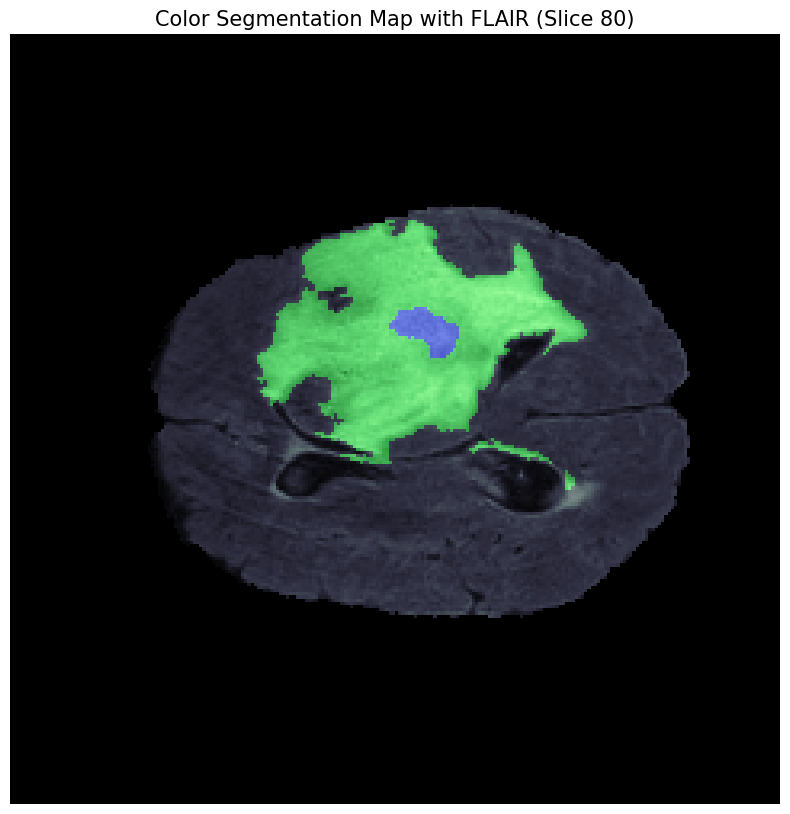

Successfully visualized slice 80 of FeTS21_Training_001


In [6]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 경로 설정 및 파일 로드
base_path = r'C:\Users\109so\OneDrive\Desktop\학교\biohealth_lv.1'
mode = 'Training'
img_id = '001'

folder_name = f'MICCAI_FeTS2021_{mode}Data'
sub_folder = f'FeTS21_{mode}_{img_id}'
full_path = os.path.join(base_path, folder_name, sub_folder)

# 파일 경로 정의 (.nii 파일)
flair_path = os.path.join(full_path, f'{sub_folder}_flair.nii')
seg_path = os.path.join(full_path, f'{sub_folder}_seg.nii')

if os.path.exists(flair_path) and os.path.exists(seg_path):
    # 데이터 로드
    flair_data = nib.load(flair_path).get_fdata()
    seg_data = nib.load(seg_path).get_fdata()
    
    # 2. 시각화할 슬라이스 선택
    slice_num = 80
    flair_slice = flair_data[:, :, slice_num]
    seg_slice = seg_data[:, :, slice_num]

    # 3. 컬러 세그멘테이션 맵 생성 (H, W, 3)
    color_segmentation = np.zeros((*seg_slice.shape, 3), dtype=np.uint8)

    # BraTS/FeTS 레이블 정의
    color_segmentation[seg_slice == 1] = [255, 0, 0]   # Red: NCR
    color_segmentation[seg_slice == 2] = [0, 255, 0]   # Green: ED
    color_segmentation[seg_slice == 4] = [0, 0, 255]   # Blue: ET

    # 4. 결과 출력
    plt.figure(figsize=(10, 10))
    plt.imshow(flair_slice, cmap='bone')
    
    # 배경(0)이 아닌 부분만 겹쳐 보이기 위해 마스킹 처리된 이미지를 띄움
    # 모든 값이 0인 픽셀은 투명하게 처리하기 위해 0이 아닌 곳만 alpha 적용
    plt.imshow(color_segmentation, alpha=0.4)
    
    plt.title(f'Color Segmentation Map with FLAIR (Slice {slice_num})', fontsize=15)
    plt.axis('off')
    plt.show()

    print(f"Successfully visualized slice {slice_num} of {sub_folder}")
else:
    print("Error: 파일을 찾을 수 없습니다. 경로와 파일명을 확인해주세요.")
    print(f"Checked path: {flair_path}")

In [7]:
smap=np.zeros((240,240,3))

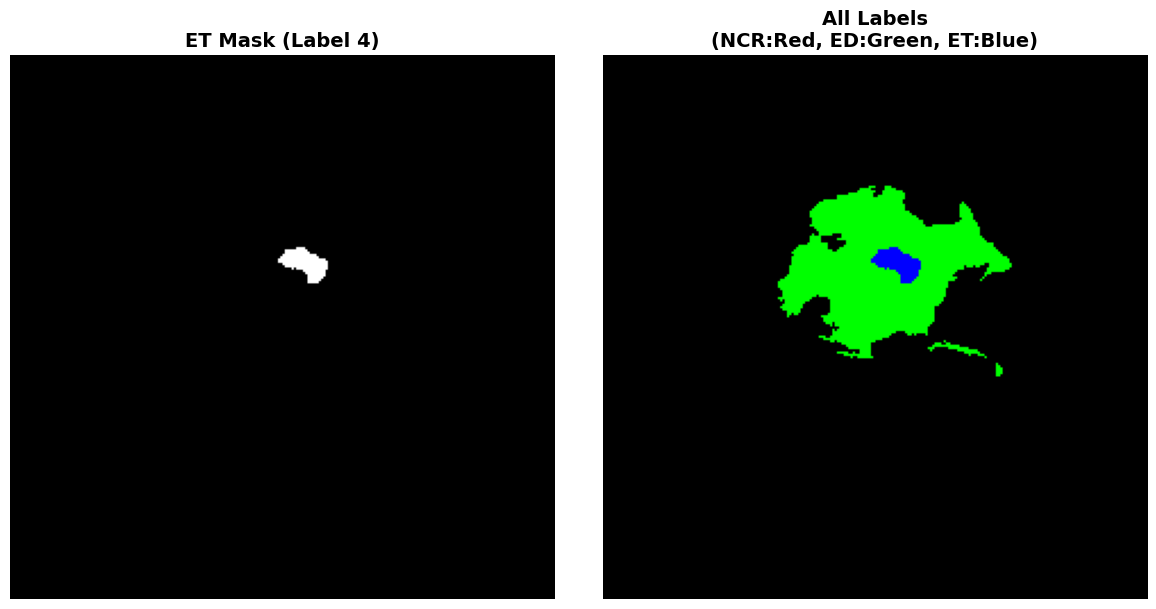

--- Analysis Report ---
ET (Label 4) Pixel Count in this slice: 199.0


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ET(Enhancing Tumor) 바이너리 마스크 생성
# gray_segmentation은 앞선 코드에서 로드된 특정 슬라이스의 레이블 데이터입니다.
# shape: (240, 240)
et_mask = np.zeros_like(seg_slice) # 0으로 채워진 빈 배열 생성
et_mask[seg_slice == 4] = 1        # 레이블이 4인 곳만 1로 설정

# 2. 시각화 (1행 2열 구조)
plt.figure(figsize=(12, 6))

# 왼쪽: ET 부위만 추출한 바이너리 마스크
plt.subplot(1, 2, 1)
plt.title('ET Mask (Label 4)', fontsize=14, fontweight='bold')
# 바이너리 마스크이므로 bone보다는 gray나 투명도 확인이 쉬운 cmap 권장
plt.imshow(et_mask, cmap='gray') 
plt.axis('off')

# 오른쪽: 전체 컬러 세그멘테이션 결과 (비교용)
plt.subplot(1, 2, 2)
plt.title('All Labels\n(NCR:Red, ED:Green, ET:Blue)', fontsize=14, fontweight='bold')
# color_segmentation은 (240, 240, 3) RGB 배열입니다.
plt.imshow(color_segmentation)
plt.axis('off')

plt.tight_layout()
plt.show()

# 3. 정량적 분석 출력
et_pixel_count = np.sum(et_mask)
print(f"--- Analysis Report ---")
print(f"ET (Label 4) Pixel Count in this slice: {et_pixel_count}")

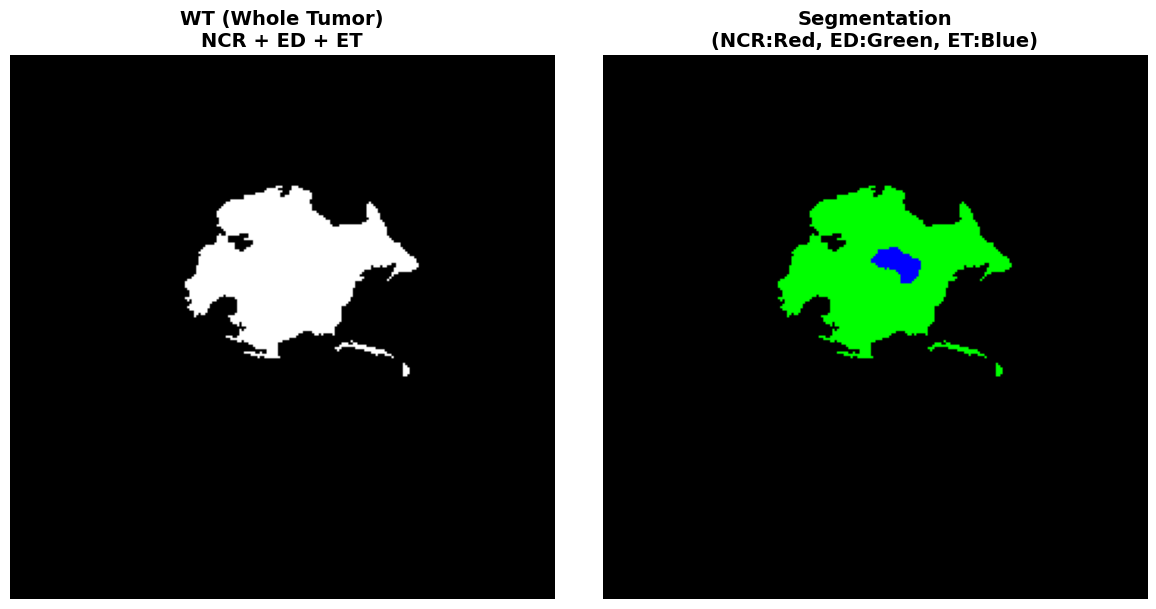

--- Whole Tumor Analysis ---
WT Pixel Count: 4217.0


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. WT(Whole Tumor) 바이너리 마스크 생성
# WT는 NCR(1), ED(2), ET(4)를 모두 포함하는 영역입니다.
wt_mask = np.zeros_like(seg_slice)

# 논리 연산자(|)를 사용하여 1, 2, 4 레이블이 있는 모든 곳을 1로 설정
wt_mask[(seg_slice == 1) | (seg_slice == 2) | (seg_slice == 4)] = 1

# 2. 시각화 (1행 2열)
plt.figure(figsize=(12, 6))

# 왼쪽: Whole Tumor 마스크
plt.subplot(1, 2, 1)
plt.title('WT (Whole Tumor)\nNCR + ED + ET', fontsize=14, fontweight='bold')
plt.imshow(wt_mask, cmap='gray') # 이진 마스크는 gray가 구분이 쉽습니다.
plt.axis('off')

# 오른쪽: 전체 컬러 세그멘테이션 결과 (비교용)
plt.subplot(1, 2, 2)
plt.title('Segmentation\n(NCR:Red, ED:Green, ET:Blue)', fontsize=14, fontweight='bold')
plt.imshow(color_segmentation)
plt.axis('off')

plt.tight_layout()
plt.show()

# 3. 데이터 분석 출력
wt_pixel_count = np.sum(wt_mask)
print(f"--- Whole Tumor Analysis ---")
print(f"WT Pixel Count: {wt_pixel_count}")

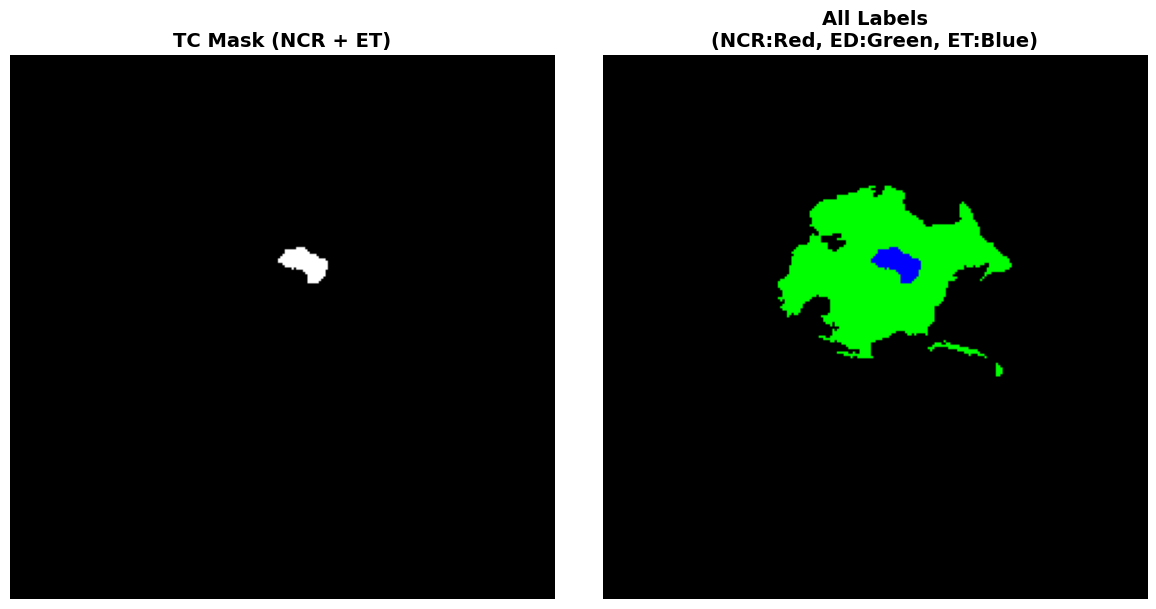

--- Analysis Report ---
TC (Tumor Core) Pixel Count: 199.0


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. TC (Tumor Core) 바이너리 마스크 생성
# TC = Label 1 (NCR) + Label 4 (ET)
tc_mask = np.zeros_like(seg_slice)

# 논리 합(|) 연산을 사용하여 1번과 4번 레이블을 한 번에 추출
tc_mask[(seg_slice == 1) | (seg_slice == 4)] = 1

# 2. 시각화 (1행 2열)
plt.figure(figsize=(12, 6))

# 왼쪽: TC (NCR + ET) 마스크
plt.subplot(1, 2, 1)
plt.title('TC Mask (NCR + ET)', fontsize=14, fontweight='bold')
plt.imshow(tc_mask, cmap='gray') # 이진 마스크는 gray가 직관적입니다.
plt.axis('off')

# 오른쪽: 전체 컬러 세그멘테이션 (비교용)
plt.subplot(1, 2, 2)
plt.title('All Labels\n(NCR:Red, ED:Green, ET:Blue)', fontsize=14, fontweight='bold')
plt.imshow(color_segmentation)
plt.axis('off')

plt.tight_layout()
plt.show()

# 3. 정량적 분석
tc_pixel_count = np.sum(tc_mask)
print(f"--- Analysis Report ---")
print(f"TC (Tumor Core) Pixel Count: {tc_pixel_count}")

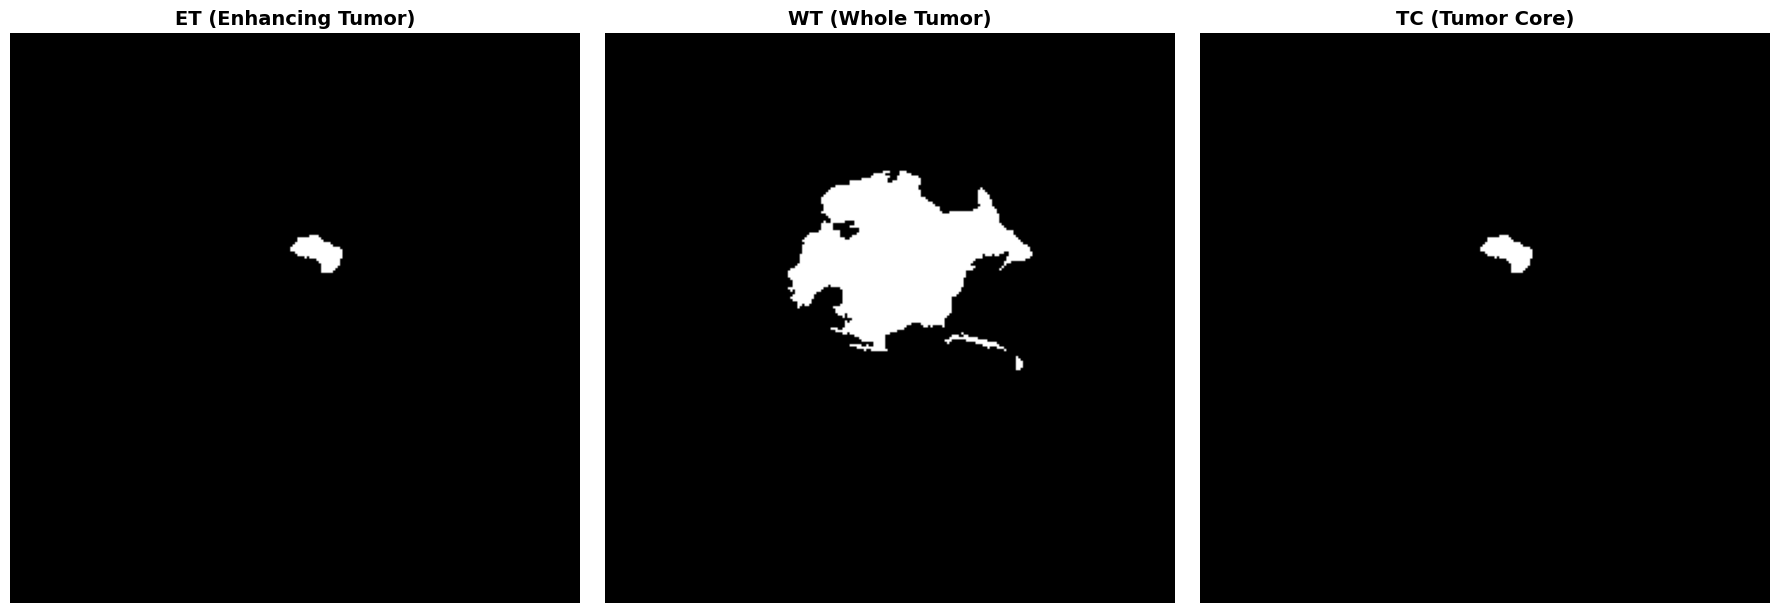

--- Volume Analysis (Pixels) ---
ET Count: 199.0 | WT Count: 4217.0 | TC Count: 199.0


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 각 영역별 바이너리 마스크 생성
# ET (Enhancing Tumor): Label 4
et_mask = np.zeros_like(seg_slice)
et_mask[seg_slice == 4] = 1

# WT (Whole Tumor): Label 1 + 2 + 4 (전체 종양 부위)
wt_mask = np.zeros_like(seg_slice)
wt_mask[(seg_slice == 1) | (seg_slice == 2) | (seg_slice == 4)] = 1

# TC (Tumor Core): Label 1 + 4 (핵심 종양 부위)
tc_mask = np.zeros_like(seg_slice)
tc_mask[(seg_slice == 1) | (seg_slice == 4)] = 1

# 2. 시각화 (1행 3열)
plt.figure(figsize=(18, 6))

# ET 시각화
plt.subplot(1, 3, 1)
plt.title('ET (Enhancing Tumor)', fontsize=14, fontweight='bold')
plt.imshow(et_mask, cmap='gray')
plt.axis('off')

# WT 시각화
plt.subplot(1, 3, 2)
plt.title('WT (Whole Tumor)', fontsize=14, fontweight='bold')
plt.imshow(wt_mask, cmap='gray')
plt.axis('off')

# TC 시각화
plt.subplot(1, 3, 3)
plt.title('TC (Tumor Core)', fontsize=14, fontweight='bold')
plt.imshow(tc_mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# 3. 데이터 요약 출력
print(f"--- Volume Analysis (Pixels) ---")
print(f"ET Count: {np.sum(et_mask)} | WT Count: {np.sum(wt_mask)} | TC Count: {np.sum(tc_mask)}")